In [1]:
'''
In this file, we will work on implementing the Zermelo problem, with some new changes:
- No obstacles
- The state evolution will be deterministic, as it is when one specifies a flight trajectory
- The pseudoloss will aim to encapsulate fuel cost by penalising the cubic of the difference between prescribed and wind velocity
- Of course, it may be difficult to balance this with the cost associated to reaching the destination
- We will set harsh constraints on the maximum and minimum velocities via a sigmoid
- We will model vertical wind via a Brownian bridge from w_min to w_max. No horizontal component just yet

It will be interesting also to investigate whether randomised base policies help (to augment the reference trajectories)
'''

'\nIn this file, we will work on implementing the Zermelo problem, with some new changes:\n- No obstacles\n- The state evolution will be deterministic, as it is when one specifies a flight trajectory\n- The pseudoloss will aim to encapsulate fuel cost by penalising the cubic of the difference between prescribed and wind velocity\n- Of course, it may be difficult to balance this with the cost associated to reaching the destination\n- We will set harsh constraints on the maximum and minimum velocities via a sigmoid\n- We will model vertical wind via a Brownian bridge from w_min to w_max. No horizontal component just yet\n\nIt will be interesting also to investigate whether randomised base policies help (to augment the reference trajectories)\n'

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib import animation
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
import time
import os
from ipywidgets import interact, IntSlider

In [3]:
# will aim to traverse from (-10, 0) to (10, 0).
# speed of reference trajectories will be 2 units per time step, thus we use time horizon of 10 steps
# will experiment with values for w_min and w_max

def OU_process(x0, sd, theta, mu, sigma, T, time_step):
    total_steps = int(T / time_step)
    process = np.zeros(total_steps + 1, dtype = float)
    process[0] = np.random.normal(loc = x0, scale = sd)
    for t in range(total_steps):
        process[t + 1] = process[t] + theta * (mu - process[t]) * time_step + sigma * np.sqrt(time_step) * np.random.normal()
    return process.astype(np.float32)

def winds(a, b, T, time_step, sigma, theta):
    """
    Simulate OU processes around a and b, then interpolate over the time steps to create an approximate move from a to b over time T, 
    kind of like a wind forecast
    """
    # don't bother with hyperparameters for OU process, just input here
    total_steps = int(T / time_step)
    ou_a = OU_process(a, 0.1, theta, a, sigma, T, time_step)
    ou_b = OU_process(b, 0.1, theta, b, sigma, T, time_step)[::-1]
    interpolants_b = np.linspace(0, 1, total_steps + 1, dtype = np.float32)
    interpolants_a = 1 - interpolants_b
    wind_process = interpolants_a * ou_a + interpolants_b * ou_b
    return wind_process.astype(np.float32)

Text(0.5, 1.0, 'Sample Winds')

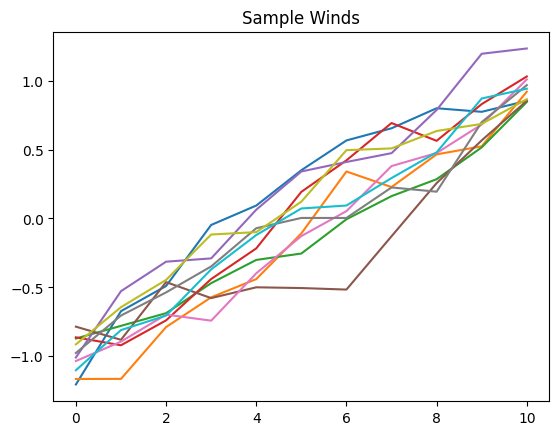

In [4]:
for i in range(10):
    plt.plot(winds(-1, 1, 10, 1, 0.2, 0.1))
plt.title("Sample Winds")

In [5]:
# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
torch.set_default_dtype(torch.float32)
print("Running on:", device)

Running on: mps


In [6]:
# define control NNs
class NeuralNet_erm(nn.Module):
    def __init__(self, input_dim, width, output_dim):
        super(NeuralNet_erm, self).__init__()
        self.hidden_layer = nn.Linear(input_dim, width)
        self.hidden_layer_2 = nn.Linear(width, width)
        self.hidden_layer_3 = nn.Linear(width, width)
        self.hidden_layer_4 = nn.Linear(width, width)
        self.sigmoid = nn.LeakyReLU()
        self.output_layer = nn.Linear(width, output_dim)
        
    def forward(self, x):
        activations_1 = self.sigmoid(self.hidden_layer(x))
        activations_2 = self.sigmoid(self.hidden_layer_2(activations_1))
        activations_3 = self.sigmoid(self.hidden_layer_3(activations_2))
        activations_4 = self.sigmoid(self.hidden_layer_4(activations_3))
        unscaled = self.output_layer(activations_4)
        return unscaled

# loss function (wind cost + terminal cost)
def running_loss(wind_value, velocity):
    a = velocity.shape[0]
    b = velocity.shape[1]
    zeros_vecs = torch.zeros((a, b, 1), device = device)
    wind_vector = torch.cat([zeros_vecs, wind_value.view(a, b, 1)], dim  = 2)
    wind_cost = torch.norm(wind_vector - velocity, dim = 2) ** 3
    return wind_cost

def terminal_loss(position, target):
    ones_vec = torch.ones_like(position, device = device)
    target_matrix = ones_vec * target
    final_cost = torch.norm(position - target_matrix, dim = 1) ** 2
    return final_cost

def penalising_velocity(velocity, min_speed, max_speed, multiplier, steepness):
    speed = torch.norm(velocity, dim = 2) # since velocities is 3D tensor
    min_cost = torch.sigmoid(steepness * (min_speed - speed))
    max_cost = torch.sigmoid(steepness * (speed - max_speed))
    return multiplier * torch.relu(min_cost + max_cost - 0.5)

# base policy randomiser function
def random_base_policy(num_policies, num_steps, min_angle, max_angle, base_speed):
    angle_matrix = torch.rand((num_policies, num_steps), device = device) * (max_angle - min_angle) + min_angle
    velocities = torch.stack((torch.cos(angle_matrix), torch.sin(angle_matrix)), dim= -1) * base_speed
    return velocities

In [7]:
# visualise trajectories for a set of random base policies
num_policies = 50
num_steps = 10
policies = random_base_policy(num_policies, num_steps, -math.pi/4, math.pi/4, 2.0)
target = torch.tensor([-10.0, 0.0], device = device)
base_trajectories = torch.zeros((num_policies, num_steps + 1, 2), device = device)
base_trajectories[:, 0, :] = target
# for t in range(num_steps):
#     base_trajectories[:, t + 1, :] = base_trajectories[:, t, :] + policies[:, t, :]
starts = torch.ones((num_policies, 1, 2), device = device) * torch.tensor([-10, 0], device = device)
trajectories = torch.cumsum(policies, dim = 1) + torch.tensor([-10, 0], device = device)
trajectories = torch.cat((starts, trajectories), dim = 1)

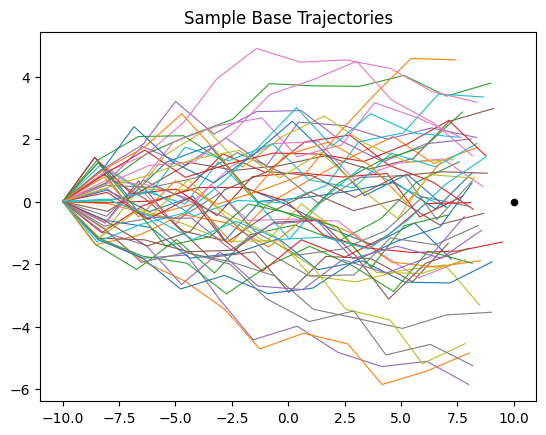

In [8]:
plt.plot(trajectories[:,:,0].cpu().numpy().T, trajectories[:,:,1].cpu().numpy().T, linewidth = 0.8)
plt.title("Sample Base Trajectories")
plt.scatter(10, 0, s = 20, color = "black")
plt.show()

In [9]:
# now, note that our training dataset will be augmented to num_sample * num_policies
def generate_training_data(a, b, T, time_step, n, num_policies, sigma, theta):
    training_data = torch.zeros((n * num_policies, int(T / time_step)), device = device)
    for i in range(n):
        bridge = torch.tensor(winds(a, b, T, time_step, sigma, theta)[: -1], device = device)
        bridge = bridge.repeat(num_policies, 1)
        training_data[i * num_policies : (i + 1) * num_policies, :] = bridge
    return training_data

In [10]:
generate_training_data(-1, 1, 10, 1, 5, 3, 0.2, 0.1)

tensor([[-1.2531, -0.9875, -0.8820, -0.4711, -0.5058,  0.0140,  0.2494,  0.5879,
          0.6594,  0.9807],
        [-1.2531, -0.9875, -0.8820, -0.4711, -0.5058,  0.0140,  0.2494,  0.5879,
          0.6594,  0.9807],
        [-1.2531, -0.9875, -0.8820, -0.4711, -0.5058,  0.0140,  0.2494,  0.5879,
          0.6594,  0.9807],
        [-1.0410, -0.8956, -0.6382, -0.4036, -0.1639,  0.0152,  0.1090,  0.3001,
          0.8271,  0.9195],
        [-1.0410, -0.8956, -0.6382, -0.4036, -0.1639,  0.0152,  0.1090,  0.3001,
          0.8271,  0.9195],
        [-1.0410, -0.8956, -0.6382, -0.4036, -0.1639,  0.0152,  0.1090,  0.3001,
          0.8271,  0.9195],
        [-0.9660, -1.1190, -0.8631, -0.5487, -0.4900, -0.2150,  0.1466,  0.4424,
          0.7909,  0.9310],
        [-0.9660, -1.1190, -0.8631, -0.5487, -0.4900, -0.2150,  0.1466,  0.4424,
          0.7909,  0.9310],
        [-0.9660, -1.1190, -0.8631, -0.5487, -0.4900, -0.2150,  0.1466,  0.4424,
          0.7909,  0.9310],
        [-1.0663, -

In [11]:
# hyperparameters
input_dim = 3
width = 500
output_dim = 2
v_min = 1
v_max = 4
velocity_penalty_multiplier = 50
target_multiplier = 10
n = 20
num_policies = 10
T = 10
time_step = 1
num_steps = int(T / time_step)
base_speed = 2
a = -1
b = 1
start_rate = 0.0001
final_rate = 0.00000001
num_epochs = 2000
target = torch.tensor([10.0, 0.0], device = device)
steepness = 5
sigma = 0.2
theta = 0.1
outer_loops = 4

In [12]:
# generate the training data
training_data = generate_training_data(a, b, T, time_step, n, num_policies, sigma, theta)

# will also need the reference trajectories (same set of num_policies for each sample)
base_policies = random_base_policy(num_policies, num_steps, -math.pi/4, math.pi/4, 2.0)
starts = torch.ones((num_policies, 1, 2), device = device) * torch.tensor([-10, 0], device = device)
ref_paths = torch.cumsum(base_policies, dim = 1) + torch.tensor([-10, 0], device = device)
ref_paths = torch.cat((starts, ref_paths), dim = 1)
# repeat for each instance of the training samples
ref_paths = ref_paths.repeat(n, 1, 1)
# training data and reference paths now fully constructed

In [13]:
# initialise models, optimisers and schedulers
models_erm = [NeuralNet_erm(input_dim, width, output_dim).to(device) for _ in range(T)]
optimisers = [optim.AdamW(model.parameters(), lr=start_rate) for model in models_erm]
schedulers = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max = num_epochs, eta_min = final_rate) for opt in optimisers]

In [18]:
Zs = np.linspace(-2, 2, 20)

# Create grid
xs = np.linspace(-10, 10, 20)
ys = np.linspace(-10, 10, 20)
X, Y = np.meshgrid(xs, ys)

def plot_quiver(model_idx, z_idx):
    model = models_erm[model_idx]
    z = Zs[z_idx]
    xy = np.stack([X.ravel(), Y.ravel(), np.full_like(X.ravel(), z)], axis=1)
    xy_tensor = torch.tensor(xy, dtype=torch.float32, device = device)
    with torch.no_grad():
        output = model(xy_tensor).cpu().numpy()

    U = output[:,0].reshape(X.shape)
    V = output[:,1].reshape(X.shape)

    # Plot quiver
    plt.figure(figsize=(10,5))
    plt.quiver(X, Y, U, V)

    for pth in range(n):
        plt.plot(current_paths[pth * num_policies, :model_idx + 1, 0].detach().cpu().numpy(), 
                 current_paths[pth * num_policies, :model_idx + 1, 1].detach().cpu().numpy(), color = 'red', linewidth = 0.5, alpha = 0.9)
        plt.plot(current_paths[pth * num_policies, model_idx:, 0].detach().cpu().numpy(), 
                 current_paths[pth * num_policies, model_idx:, 1].detach().cpu().numpy(), color = 'blue', linewidth = 0.5, alpha = 0.9)
        
    plt.title(f"PyTorch Quiver Plot | Model {model_idx+1} | Z = {z}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.xlim(-10, 10)
    plt.ylim(-10, 10)
    plt.grid(True)
    plt.show()

In [17]:
''' New idea:
Since we are modelling deterministically, instead of penalising the terminal cost as squared distance to target, 
we can just set it to be the required remaining velocity to hit the target perfectly (a deterministic object!), 
and penalise the resulting velocity decision accordingly (which is a function of T-1 th model)
'''
# generate the training data
training_data = generate_training_data(a, b, T, time_step, n, num_policies, sigma, theta)

# will also need the reference trajectories (same set of num_policies for each sample)
base_policies = random_base_policy(num_policies, num_steps, -math.pi/4, math.pi/4, 2.0)
starts = torch.ones((num_policies, 1, 2), device = device) * torch.tensor([-10, 0], device = device)
ref_paths = torch.cumsum(base_policies, dim = 1) + torch.tensor([-10, 0], device = device)
ref_paths = torch.cat((starts, ref_paths), dim = 1)
# repeat for each instance of the training samples
ref_paths = ref_paths.repeat(n, 1, 1)
# training data and reference paths now fully constructed
# initialise models, optimisers and schedulers
models_erm = [NeuralNet_erm(input_dim, width, output_dim).to(device) for _ in range(T - 1)] # final velocity is a function of prior one now
optimisers = [optim.AdamW(model.parameters(), lr=start_rate) for model in models_erm]
schedulers = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max = num_epochs, eta_min = final_rate) for opt in optimisers]

In [18]:
for loop in range(outer_loops):
    print(f"Outer loop {loop + 1}")
    for t in reversed(range(T - 1)):
        print(f"t = {t}")
        path_length = T - t
        for epoch in range(num_epochs):
            final_c = 0
            current_paths = [ref_paths[:, t, :]]
            velocities = []
            # generate path from t
            for futs in range(path_length - 1): # up until T-1 then final velocity calculated separately
                velocity = models_erm[t + futs](torch.cat([current_paths[-1],
                                                        training_data[:, t + futs].view(n * num_policies, 1)], 
                                                        dim = 1))
                current_paths.append(current_paths[-1] + time_step * velocity)
                velocities.append(velocity)
            # final velocity to hit target exactly
            final_velocity = (target - current_paths[-1]) / time_step
            velocities.append(final_velocity)
            # stack into 3D tensors
            current_paths = torch.stack(current_paths, dim = 1)
            to_add = target.repeat(n * num_policies, 1).view(n * num_policies, 1, 2)
            current_paths = torch.cat([current_paths, to_add], dim = 1)
            velocities = torch.stack(velocities, dim = 1)
            # compute losses
            safety_costs = penalising_velocity(velocities, v_min, v_max, velocity_penalty_multiplier, steepness)
            safety_costs = torch.sum(safety_costs, dim = 1)
            running_losses = running_loss(training_data[:, t:], velocities)
            running_costs = torch.sum(running_losses, dim = 1) / T # kind of normalises
            final_c = final_c + torch.mean(safety_costs + running_costs)
            # backprop
            final_c.backward()
            optimisers[t].step()
            optimisers[t].zero_grad()
            schedulers[t].step()
            if epoch % 1000 == 0:
                with torch.no_grad():
                    print(f"Epoch {epoch}, Total {final_c:.6f}, Safety {torch.mean(safety_costs):.6f}, Running {torch.mean(running_costs):.6f}")
        # freeze model after training
        for param in models_erm[t].parameters():
            param.requires_grad = False
    for model in models_erm:
        for param in model.parameters():
            param.requires_grad = True
    # reset optimisers and schedulers
    optimisers = [optim.AdamW(model.parameters(), lr=start_rate) for model in models_erm]
    schedulers = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max = num_epochs, eta_min = final_rate) for opt in optimisers]
    # new reference policies are the learned policies for this loop
    ref_paths = current_paths.detach()

Outer loop 1
t = 8
Epoch 0, Total 76.009979, Safety 49.486259, Running 26.523720
Epoch 1000, Total 7.218563, Safety 0.000000, Running 7.218563
t = 7
Epoch 0, Total 60.889259, Safety 44.998905, Running 15.890351
Epoch 1000, Total 5.852561, Safety 0.000000, Running 5.852561
t = 6
Epoch 0, Total 44.901230, Safety 32.729740, Running 12.171492
Epoch 1000, Total 5.587952, Safety 0.000000, Running 5.587952
t = 5
Epoch 0, Total 34.202633, Safety 24.633648, Running 9.568988
Epoch 1000, Total 6.014325, Safety 0.000000, Running 6.014325
t = 4
Epoch 0, Total 33.922386, Safety 24.524824, Running 9.397560
Epoch 1000, Total 6.337094, Safety 0.000000, Running 6.337094
t = 3
Epoch 0, Total 33.518368, Safety 24.373276, Running 9.145092
Epoch 1000, Total 6.787264, Safety 0.000000, Running 6.787264
t = 2
Epoch 0, Total 34.000866, Safety 24.615028, Running 9.385834
Epoch 1000, Total 7.215630, Safety 0.000000, Running 7.215630
t = 1
Epoch 0, Total 34.441650, Safety 24.600832, Running 9.840819
Epoch 1000, To

In [21]:
import time
erm_info = {
            "date": time.strftime("%Y-%m-%d", time.localtime()),
            "n": n,
            "T": T,
            "v_min": v_min,
            "v_max": v_max,
            "Target": target.cpu(),
            "velocity_penalty_multiplier": velocity_penalty_multiplier,
            "num_policies": num_policies,
            "time_step": time_step,
            "steepness" : steepness,
            "outer_loops": outer_loops,
            "theta": theta,
            "sigma": sigma,
            "activation_function": "tanh",
            "network_width": width,
            "start_rate": start_rate,
            "final_rate": final_rate,
            "num_epochs": num_epochs,
            "optimiser": "AdamW",
            "scheduler": "CosineAnnealingLR",
            "base_speed": base_speed,
            "training_data": training_data.cpu(),
            "erm_model_parameters": [model.state_dict() for model in models_erm],
            "method": "Entropy-Regularised",
            "ref_paths": ref_paths.cpu(),
            "final_paths": current_paths.cpu()
        }
# save all information
# create folder if it doesn't exist
save_dir = "fuel_dep_one_plane"
os.makedirs(save_dir, exist_ok=True)
date_str = time.strftime('%Y-%m-%d', time.localtime())
fname = os.path.join(save_dir, f"{date_str}.pt")
torch.save(erm_info, fname)

In [14]:
with open("./fuel_dep_one_plane/2025-12-03.pt", "rb") as f:
    data = torch.load(f, map_location = device)

In [15]:
n = data["n"]
T = data["T"]
v_min = data["v_min"]
v_max = data["v_max"]
target = data["Target"].to(device)
velocity_penalty_multiplier = data["velocity_penalty_multiplier"]
num_policies = data["num_policies"]
time_step = data["time_step"]
steepness = data["steepness"]
outer_loops = data["outer_loops"]
theta = data["theta"]
sigma = data["sigma"]
width = data["network_width"]
start_rate = data["start_rate"]
final_rate = data["final_rate"]
num_epochs = data["num_epochs"]
base_speed = data["base_speed"]
training_data = data["training_data"].to(device)
models_erm = []
for model_params in data["erm_model_parameters"]:
    model = NeuralNet_erm(3, width, 2).to(device)
    model.load_state_dict(model_params)
    models_erm.append(model)
ref_paths = data["ref_paths"].to(device)
current_paths = data["final_paths"].to(device)


Text(0.5, 1.0, 'Learned Trajectories')

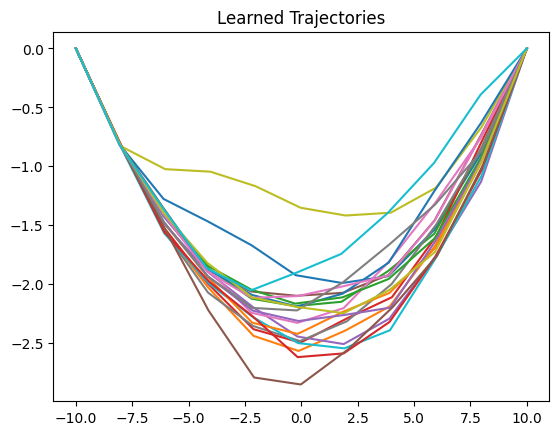

In [16]:
for pth in range(n):
    plt.plot(current_paths[pth * num_policies, :, 0].detach().cpu().numpy(), 
             current_paths[pth * num_policies, :, 1].detach().cpu().numpy())
plt.title("Learned Trajectories")

In [ ]:
interact(
    plot_quiver,
    model_idx=IntSlider(min=0, max=len(models_erm)-1, step=1, description='Model'),
    z_idx=IntSlider(min=0, max=len(Zs)-1, step=1, description='Z index')
)
plt.show()

interactive(children=(IntSlider(value=0, description='Model', max=8), IntSlider(value=0, description='Z index'…

In [140]:
''' let's now attempt for two different planes
    - attempt with crossing needed
    - then maybe with differing start times? 

We will explore differing the wind spatially, but for now keep it temporal only
'''

start1 = torch.tensor([-10.0, -5.0], device = device)
start2 = torch.tensor([-10.0, 5.0], device = device)
target1 = torch.tensor([10.0, 5.0], device = device)
target2 = torch.tensor([10.0, -5.0], device = device)
pi_tensor = torch.tensor(math.pi, device = device)
two_tensor = torch.tensor(2.0, device = device)
# write the collision-avoidance loss function
def collision_avoidance_loss(positions1, positions2, velocities1, velocities2, T, time_gap, min_distance, collision_multiplier):
    s = min_distance / torch.sqrt(torch.log(two_tensor)) 
    curr_t = T - velocities1.shape[1]
    taus = torch.linspace(0, T, steps = int(T / time_gap) + 1, device = device)[curr_t:-1] # no need to include final time
    dx = positions1 - positions2
    distances = torch.norm(dx, dim = 2) # collapses to (num_policies * n, num_steps)
    distances = torch.clamp(distances, min = 1e-3) # avoid division by zero
    dv = velocities1 - velocities2 
    magvs = torch.norm(dv, dim = 2) 
    magvs = torch.clamp(magvs, min = 1e-3) # avoid division by zero
    dotxv = torch.sum(dx * dv, dim = 2)
    exponent = (dotxv / magvs) ** 2 - 2 * distances
    exponent = torch.clamp(exponent, min=-50, max=50)
    exp_component = torch.exp(exponent / (s ** 2))
    # print(dotxv)
    # print(magvs)
    # print(distances)
    factor = collision_multiplier * ( s * torch.sqrt(pi_tensor)) / (2 * magvs)
    time1 = magvs / s * (taus + dotxv / (magvs ** 2))
    time2 = magvs / s * (taus + dotxv / (magvs ** 2) + time_gap)
    collision_costs = factor * exp_component * (torch.erf(time2) - torch.erf(time1))
    return collision_costs

def continuous_collision_loss(positions1, positions2, velocities1, velocities2, 
                              eta, min_distance, weight):
    dx = positions1 - positions2
    dv = velocities1 - velocities2
    dv_norm_sq = torch.sum(dv**2, dim=2, keepdim = True) + 1e-6 # for stability
    tau_star = - torch.sum(dx * dv, dim=2, keepdim = True) / dv_norm_sq 
    tau_star = torch.clamp(tau_star, 0.0, eta)
    closest_point = dx + tau_star * dv
    d_min = torch.norm(closest_point, dim=2)
    penetration = torch.clamp(min_distance - d_min, min=0)
    return weight * penetration ** 2

In [141]:
# hyperparameters
input_dim = 5
width = 500
output_dim = 4
v_min = 1
v_max = 4
velocity_penalty_multiplier = 50
collision_multiplier = 1
min_distance = 1.0
n = 20
num_policies = 10
T = 10
time_step = 1
num_steps = int(T / time_step)
base_speed = 2
a = -1
b = 1
start_rate = 0.001
final_rate = 0.000001
num_epochs = 2000
steepness = 5
sigma = 0.2
theta = 0.1
outer_loops = 4
# generate the training data
training_data = generate_training_data(a, b, T, time_step, n, num_policies, sigma, theta)

# will also need the reference trajectories (same set of num_policies for each sample)
base_policies1 = random_base_policy(num_policies, num_steps, -math.pi/4, math.pi/4, 2.0)
base_policies2 = random_base_policy(num_policies, num_steps, -math.pi/4, math.pi/4, 2.0)

starts1 = torch.ones((num_policies, 1, 2), device = device) * start1
starts2 = torch.ones((num_policies, 1, 2), device = device) * start2
ref_paths1 = torch.cumsum(base_policies1, dim = 1) + start1
ref_paths1 = torch.cat((starts1, ref_paths1), dim = 1)
ref_paths2 = torch.cumsum(base_policies2, dim = 1) + start2
ref_paths2 = torch.cat((starts2, ref_paths2), dim = 1)
# repeat for each instance of the training samples
ref_paths1 = ref_paths1.repeat(n, 1, 1)
ref_paths2 = ref_paths2.repeat(n, 1, 1)
# training data and reference paths now fully constructed
# initialise models, optimisers and schedulers
models_erm = [NeuralNet_erm(input_dim, width, output_dim).to(device) for _ in range(T - 1)] # final velocity is a function of prior one now
optimisers = [optim.AdamW(model.parameters(), lr=start_rate) for model in models_erm]
schedulers = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max = num_epochs, eta_min = final_rate) for opt in optimisers]

In [143]:
for loop in range(outer_loops):
    print(f"Outer loop {loop}")
    for t in reversed(range(T - 1)):
        print(f"t = {t}")
        path_length = T - t
        for epoch in range(num_epochs):
            final_c = 0
            current_paths = [torch.cat([ref_paths1[:, t, :], ref_paths2[:, t, :]], dim = 1)]
            velocities = []
            # generate path from t
            for futs in range(path_length - 1): # up until T-1 then final velocity calculated separately
                velocity = models_erm[t + futs](torch.cat([current_paths[-1],
                                                        training_data[:, t + futs].view(n * num_policies, 1)], 
                                                        dim = 1))
                current_paths.append(current_paths[-1] + time_step * velocity)
                velocities.append(velocity)
            # final velocity to hit target exactly
            combined_targets = torch.cat([target1, target2], dim = 0)
            final_velocity = (combined_targets - current_paths[-1]) / time_step
            velocities.append(final_velocity)
            # stack into 3D tensors
            current_paths = torch.stack(current_paths, dim = 1) # shape is (n * num_policies, path_length, 4)
            to_add = combined_targets.repeat(n * num_policies, 1).view(n * num_policies, 1, 4)
            current_paths = torch.cat([current_paths, to_add], dim = 1)
            velocities = torch.stack(velocities, dim = 1)
            # compute losses
            safety_costs1 = penalising_velocity(velocities[:, :, :2], v_min, v_max, velocity_penalty_multiplier, steepness)
            safety_costs2 = penalising_velocity(velocities[:, :, 2:], v_min, v_max, velocity_penalty_multiplier, steepness)
            safety_costs = torch.sum(safety_costs1 + safety_costs2, dim = 1)
            running_losses1 = running_loss(training_data[:, t:], velocities[:, :, :2])
            running_losses2 = running_loss(training_data[:, t:], velocities[:, :, 2:])
            running_costs = torch.sum(running_losses1 + running_losses2, dim = 1) / T # kind of normalises
            # collision_costs = continuous_collision_loss(current_paths[:, :-1, :2], 
            #                                            current_paths[:, :-1, 2:], 
            #                                            velocities[:, :, :2],
            #                                            velocities[:, :, 2:],
            #                                            eta = time_step,
            #                                            min_distance = min_distance,
            #                                            weight = collision_multiplier)
            # collision_costs = torch.sum(collision_costs, dim = 1)
            final_c = final_c + torch.mean(safety_costs / 2 + running_costs / 2)
            # backprop
            final_c.backward()
            optimisers[t].step()
            optimisers[t].zero_grad()
            schedulers[t].step()
            if epoch % 1000 == 0:
                with torch.no_grad():
                    print(f"Epoch {epoch}, Total {final_c:.6f}, Safety {torch.mean(safety_costs):.6f}, Running {torch.mean(running_costs):.6f}") #,Collision {torch.mean(collision_costs):.6f}")
        # freeze model after training
        for param in models_erm[t].parameters():
            param.requires_grad = False
    for model in models_erm:
        for param in model.parameters():
            param.requires_grad = True
    # reset optimisers and schedulers
    optimisers = [optim.AdamW(model.parameters(), lr=start_rate) for model in models_erm]
    schedulers = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max = num_epochs, eta_min = final_rate) for opt in optimisers]
    # new reference policies are the learned policies for this loop
    ref_paths = current_paths.detach()

Outer loop 0
t = 8
Epoch 0, Total 229.814987, Safety 98.790039, Running 360.839935
Epoch 1000, Total 85.998672, Safety 66.935127, Running 105.062218
t = 7
Epoch 0, Total 144.195129, Safety 122.605896, Running 165.784378
Epoch 1000, Total 49.043736, Safety 42.799843, Running 55.287628
t = 6
Epoch 0, Total 130.254517, Safety 105.798203, Running 154.710846
Epoch 1000, Total 22.798656, Safety 6.083841, Running 39.513474
t = 5
Epoch 0, Total 100.063232, Safety 116.349831, Running 83.776634
Epoch 1000, Total 17.934387, Safety 0.076847, Running 35.791927
t = 4
Epoch 0, Total 73.152084, Safety 96.521072, Running 49.783096
Epoch 1000, Total 17.289549, Safety 0.022421, Running 34.556675
t = 3
Epoch 0, Total 51.353390, Safety 60.422852, Running 42.283920
Epoch 1000, Total 17.168110, Safety 0.023997, Running 34.312225
t = 2
Epoch 0, Total 48.237492, Safety 56.053589, Running 40.421398
Epoch 1000, Total 17.367695, Safety 0.030756, Running 34.704636
t = 1
Epoch 0, Total 47.045528, Safety 53.327248, 

KeyboardInterrupt: 

Text(0.5, 1.0, 'Learned Trajectories for Two Planes')

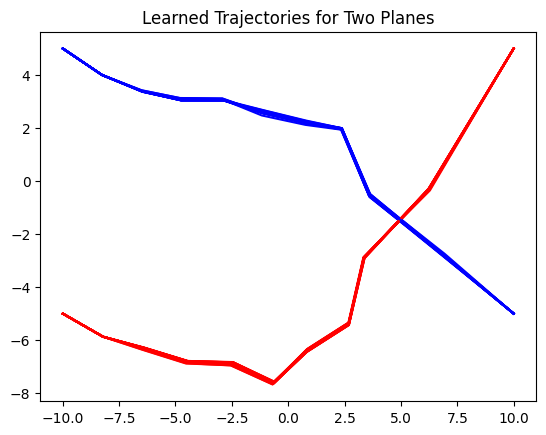

In [80]:
for pth in range(n):
    plt.plot(current_paths[pth * num_policies, :, 0].detach().cpu().numpy(), 
             current_paths[pth * num_policies, :, 1].detach().cpu().numpy(), color = 'red')
    plt.plot(current_paths[pth * num_policies, :, 2].detach().cpu().numpy(), 
             current_paths[pth * num_policies, :, 3].detach().cpu().numpy(), color = 'blue')
plt.title("Learned Trajectories for Two Planes")

In [119]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def interpolate_trajectory(positions, n_interp=10):
    """
    Linearly interpolate positions between timesteps to make animation smoother.
    positions: [T, 4] (single sample)
    Returns: [T * n_interp, 4]
    """
    T = positions.shape[0]
    interp_positions = []
    for t in range(T - 1):
        start = positions[t]
        end = positions[t + 1]
        for i in range(n_interp):
            alpha = i / n_interp
            interp = (1 - alpha) * start + alpha * end
            interp_positions.append(interp)
    interp_positions.append(positions[-1])  # include last timestep
    return np.stack(interp_positions, axis=0)

def animate_smooth_positions(current_paths, sample_idx=0, interval=50, n_interp=10):
    pos = current_paths[sample_idx].detach().cpu().numpy()  # [T, 4]
    smooth_pos = interpolate_trajectory(pos, n_interp=n_interp)
    
    x1, y1 = smooth_pos[:, 0], smooth_pos[:, 1]
    x2, y2 = smooth_pos[:, 2], smooth_pos[:, 3]

    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)

    line1, = ax.plot([], [], 'b-', label='Plane 1')
    line2, = ax.plot([], [], 'r-', label='Plane 2')
    point1, = ax.plot([], [], 'bo')
    point2, = ax.plot([], [], 'ro')
    ax.legend()

    def init():
        line1.set_data([], [])
        line2.set_data([], [])
        point1.set_data([], [])
        point2.set_data([], [])
        return line1, line2, point1, point2

    def update(frame):
        line1.set_data(x1[:frame+1], y1[:frame+1])
        line2.set_data(x2[:frame+1], y2[:frame+1])
        point1.set_data([x1[frame]], [y1[frame]])
        point2.set_data([x2[frame]], [y2[frame]])
        return line1, line2, point1, point2

    ani = FuncAnimation(fig, update, frames=len(x1), init_func=init, interval=interval, blit=False)
    return HTML(ani.to_jshtml())




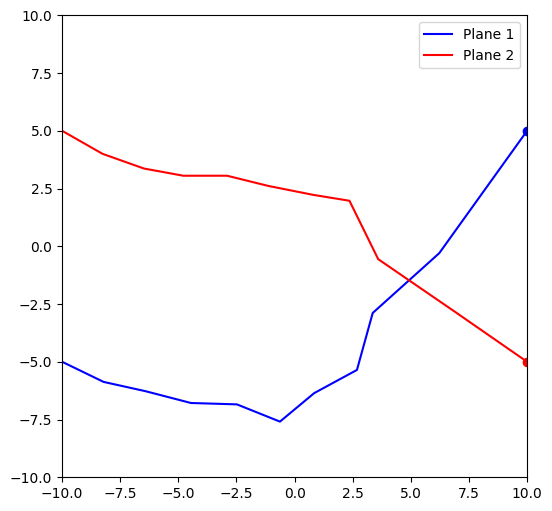

In [120]:
animate_smooth_positions(current_paths, sample_idx=3, interval=150, n_interp=10)

In [106]:
pos = current_paths[0, :, :].detach().cpu().numpy()
x1, y1 = pos[:, 0], pos[:, 1]
x2, y2 = pos[:, 2], pos[:, 3]

In [22]:
interact(
    plot_quiver,
    model_idx=IntSlider(min=0, max=len(models_erm)-1, step=1, description='Model'),
    z_idx=IntSlider(min=0, max=len(Zs)-1, step=1, description='Z index')
)
plt.show()

interactive(children=(IntSlider(value=0, description='Model', max=8), IntSlider(value=0, description='Z index'…